# AI Product Discovery with RAG (Notebook Structure)

This notebook is the **orchestrator** for your repo-based implementation:

- `src/` holds core pipeline logic (cleaning, embeddings, FAISS, ranking, RAG, UI)
- `notebooks/` demonstrates the end-to-end workflow with plots + examples
- `data/` and `artifacts/` are **gitignored**

> **Colab tip**: If running in Colab, clone your repo and run from the repo root.


In [3]:
# Determine if running in Colab (robust, no import errors)
import sys, os

def in_colab() -> bool:
    # Safest: try importing google.colab (catch if package doesn't exist)
    try:
        import google.colab  # type: ignore
        return True
    except Exception:
        pass
    # Secondary: module already loaded
    if 'google.colab' in sys.modules:
        return True
    # Optional: environment hints
    return any(k in os.environ for k in ['COLAB_RELEASE_TAG','COLAB_GPU','COLAB_TPU_ADDR'])

if in_colab():
    from google.colab import drive
    drive.mount('/content/drive')
    # change the cwd to the notebooks
    os.chdir("/content/drive/MyDrive/pyramyd_ml")

    # Optional: !pip -q install -r requirements.txt
else:
    print('Running outside Colab')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
%%bash
export IN_COLAB=0
if python3 -c "import sys; import google.colab" &> /dev/null; then
  IN_COLAB=1
fi

if [ $IN_COLAB -eq 1 ]; then
    set -e
    # Mount Drive first (if not already)
    # python code runs before bash usually, so keep mount in Python cell above
    # Link persistent SSH config into runtime
    mkdir -p ~/.ssh
    ln -sf /content/drive/MyDrive/.ssh/id_ed25519 ~/.ssh/id_ed25519
    ln -sf /content/drive/MyDrive/.ssh/id_ed25519.pub ~/.ssh/id_ed25519.pub
    ln -sf /content/drive/MyDrive/.ssh/known_hosts ~/.ssh/known_hosts

    chmod 700 ~/.ssh
    chmod 600 ~/.ssh/id_ed25519
    chmod 644 ~/.ssh/id_ed25519.pub

    echo "SSH ready."

    git config --global user.name "Colab"
    git config --global user.email "shizhe_zhang@berkeley.edu"
    ssh -T git@github.com || true
fi


SSH ready.


Hi minikouda/pyramyd_ml! You've successfully authenticated, but GitHub does not provide shell access.


In [7]:
# Ensure repo root is on sys.path so `import src.*` works
# !pwd
# !ls
from pathlib import Path

cwd = Path.cwd()

# If running from repo root, keep it; if from notebooks/, go up one level
if (cwd / 'src').exists():
    repo_root = cwd
elif (cwd.name == 'notebooks') and ((cwd.parent / 'src').exists()):
    repo_root = cwd.parent
    cwd = cwd.parent
else:
    # Fallback: search upwards for a folder containing `src` and `requirements.txt`
    candidates = [cwd, *cwd.parents]
    repo_root = next((p for p in candidates if (p / 'src').exists()), cwd)

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

print('Repo root:', repo_root)
print('CWD:', cwd)
print('sys.path[0]:', sys.path[0])

Repo root: /content/drive/MyDrive/pyramyd_ml
CWD: /content/drive/MyDrive/pyramyd_ml
sys.path[0]: /content/drive/MyDrive/pyramyd_ml


In [5]:
# Install dependencies (Colab-only). Locally, use: pip install -r requirements.txt
# !pip -q install -r requirements.txt

import os, re, json, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Repo modules
from src.config import EMBED_MODEL, LLM_MODEL, ARTIFACT_DIR
from src.data import load_data

# Uncomment as you implement these modules
# from src.embeddings import embed_texts
# from src.index import build_index
# from src.ranker import hybrid_score
# from src.rag import build_prompt

os.makedirs(ARTIFACT_DIR, exist_ok=True)
print("EMBED_MODEL:", EMBED_MODEL)
print("LLM_MODEL:", LLM_MODEL)
print("ARTIFACT_DIR:", ARTIFACT_DIR)


EMBED_MODEL: BAAI/bge-large-en-v1.5
LLM_MODEL: Qwen/Qwen2.5-7B-Instruct
ARTIFACT_DIR: /content/drive/MyDrive/pyramyd_ml/artifacts


## 2) Load CSV + Inspect


In [8]:
# Path options:
# - In Colab: upload to /content, or mount Google Drive
# - Locally: point to your local file

CSV_PATH = "data/company_reviews.csv"

df_raw = load_data(os.path.join(cwd, CSV_PATH))

print("Shape:", df_raw.shape)
display(df_raw.head(3))

# Quick schema + missingness
col_info = pd.DataFrame({
    "col": df_raw.columns,
    "dtype": [str(df_raw[c].dtype) for c in df_raw.columns],
    "missing_%": [df_raw[c].isna().mean()*100 for c in df_raw.columns],
}).sort_values("missing_%", ascending=False)

display(col_info)


Shape: (17050, 20)


,name,rating,reviews,description,happiness,ceo_approval,ceo_count,ratings,locations,roles,salary,interview_experience,interview_difficulty,interview_duration,interview_count,headquarters,employees,industry,revenue,website
0,Sitel,NaN,NaN,"Sitel Group’s 75,000 people across the globe c...","{'Work Happiness Score': '55', 'Achievement': ...",70%,"CEO Approval is based on 4,612 ratings","{'Work/Life Balance': '3.4', 'Compensation/Ben...","{'Paradise, NV': '5.0', 'Pioneer, OH': '4.7', ...","{'Tier 1 Agent': '5.0', 'Director of Operation...",{'Customer Service Representative': '$14.48 pe...,Favorable,Easy,About a day or two,Based on 645 interviews,"600 Brickell Ave Miami, FL 33131 Vereinigte St...","10,000+",Telecommunications,$1B to $5B (USD),Twitter\nFacebook\nSitel website
1,Meadowbrook Rehabilitation,3.7,21 reviews,You'll work with the most experienced and loya...,{},NaN,NaN,"{'Work/Life Balance': '4.1', 'Compensation/Ben...",{},{},{},Favorable,Easy,NaN,Based on 5 interviews,Illinois,NaN,Healthcare,NaN,Meadowbrook Rehabilitation website
2,Intermountain,4.0,23 reviews,Why Intermountain?\n\nWe Bring Hope\n\nWith ou...,{},88%,CEO Approval is based on 17 ratings,"{'Work/Life Balance': '3.5', 'Compensation/Ben...",{},{},{'Mental Health Technician': '$13.16 per hour'...,Favorable,Medium,About a day or two,Based on 8 interviews,"Headquarters: 3240 Dredge Dr. Helena, MT 59602",201 to 500,Healthcare,$5M to $25M (USD),Twitter\nFacebook\nIntermountain website


,col,dtype,missing_%
18,revenue,object,40.310850
13,interview_duration,object,39.460411
6,ceo_count,object,34.181818
5,ceo_approval,object,34.181818
12,interview_difficulty,object,32.774194
14,interview_count,object,32.557185
11,interview_experience,object,32.557185
16,employees,object,11.888563
17,industry,object,10.826979
15,headquarters,object,10.674487


## 3) Cleaning & Parsing


In [40]:
# Import reusable cleaners from src/ (source of truth)
from src.data import to_float, parse_listish, parse_salary

df = df_raw.copy()
df.columns = [c.strip().lower() for c in df.columns]

#Discard the row if name is missing
df = df.dropna(subset=["name"])

# Numeric columns (edit as needed)
for c in ["rating", "happiness", "ceo_approval", "interview_difficulty", "interview_experience"]:
    if c in df.columns:
        df[c] = df[c].apply(to_float)

# List-like columns (edit as needed)
for c in ["roles", "locations", "ratings"]:
    if c in df.columns:
        df[c] = df[c].apply(parse_listish)

# Salary parsing
if "salary" in df.columns:
    parsed = df["salary"].apply(parse_salary)
    df["salary_min"] = [t[0] for t in parsed]
    df["salary_max"] = [t[1] for t in parsed]
    df["salary_median"] = [t[2] for t in parsed]

# Build doc text
text_cols = [c for c in ["description", "reviews"] if c in df.columns]
df["doc_text"] = df[text_cols].fillna("").astype(str).agg("\n".join, axis=1).str.replace(r"\s+", " ", regex=True).str.strip()

df_clean = df
print("Clean shape:", df_clean.shape)
display(df_clean.head(10))

df['salary_max'].describe()


Clean shape: (16712, 24)


,name,rating,reviews,description,happiness,ceo_approval,ceo_count,ratings,locations,roles,...,interview_count,headquarters,employees,industry,revenue,website,salary_min,salary_max,salary_median,doc_text
0,Sitel,NaN,NaN,"Sitel Group’s 75,000 people across the globe c...",NaN,70.0,"CEO Approval is based on 4,612 ratings","[{'Work/Life Balance': '3.4', 'Compensation/Be...","[{'Paradise, NV': '5.0', 'Pioneer, OH': '4.7',...","[{'Tier 1 Agent': '5.0', 'Director of Operatio...",...,Based on 645 interviews,"600 Brickell Ave Miami, FL 33131 Vereinigte St...","10,000+",Telecommunications,$1B to $5B (USD),Twitter\nFacebook\nSitel website,11.44,14.48,12.960,"Sitel Group’s 75,000 people across the globe c..."
1,Meadowbrook Rehabilitation,3.7,21 reviews,You'll work with the most experienced and loya...,NaN,NaN,NaN,"[{'Work/Life Balance': '4.1', 'Compensation/Be...",[{}],[{}],...,Based on 5 interviews,Illinois,NaN,Healthcare,NaN,Meadowbrook Rehabilitation website,NaN,NaN,NaN,You'll work with the most experienced and loya...
2,Intermountain,4.0,23 reviews,Why Intermountain?\n\nWe Bring Hope\n\nWith ou...,NaN,88.0,CEO Approval is based on 17 ratings,"[{'Work/Life Balance': '3.5', 'Compensation/Be...",[{}],[{}],...,Based on 8 interviews,"Headquarters: 3240 Dredge Dr. Helena, MT 59602",201 to 500,Healthcare,$5M to $25M (USD),Twitter\nFacebook\nIntermountain website,13.16,749.00,381.080,Why Intermountain? We Bring Hope With our holi...
3,Smith & Nephew,NaN,NaN,It's more than business at Smith+Nephew - it's...,NaN,76.0,CEO Approval is based on 374 ratings,"[{'Work/Life Balance': '3.5', 'Compensation/Be...","[{'Largo, FL': '4.5', 'Chicago, IL': '4.3', 'S...","[{'Packaging Technician': '5.0', 'Senior Assoc...",...,Based on 116 interviews,"Building 5, Croxley Park, Hatters Lane, Watfor...","10,000+",Healthcare,$1B to $5B (USD),Twitter\nFacebook\nSmith & Nephew website,6.00,326.00,166.000,It's more than business at Smith+Nephew - it's...
4,Reverse Mortgage Funding,4.1,19 reviews,Reverse Mortgage Funding LLC is committed to e...,NaN,NaN,NaN,"[{'Work/Life Balance': '4.2', 'Compensation/Be...",[{}],[{}],...,Based on 5 interviews,Bloomfield,11 to 50,Financial Services,$5M to $25M (USD),Reverse Mortgage Funding website,NaN,NaN,NaN,Reverse Mortgage Funding LLC is committed to e...
5,VeriFone,3.4,437 reviews,Verifone is an American multinational corporat...,NaN,57.0,CEO Approval is based on 199 ratings,"[{'Work/Life Balance': '3.4', 'Compensation/Be...","[{'Scottsdale, AZ': '4.3', 'Las Vegas, NV': '4...","[{'Workday HCM Consultant': '5.0', 'Software T...",...,Based on 62 interviews,"San Jose, CA","5,001 to 10,000",Manufacturing,$1B to $5B (USD),Facebook\nVeriFone website,29.97,979.00,504.485,Verifone is an American multinational corporat...
6,VBM Auto Group,3.5,45 reviews,This company is family owned and operated with...,NaN,67.0,CEO Approval is based on 27 ratings,"[{'Work/Life Balance': '3.2', 'Compensation/Be...","[{'New Braunfels, TX': '4.0', 'San Antonio, TX...","[{'Receptionist': '4.7', 'Internet Sales': '3....",...,Based on 14 interviews,Boerne,51 to 200,Automotive,NaN,Twitter\nFacebook\n...more,3.00,150.00,76.500,This company is family owned and operated with...
7,American National Insurance Company,3.5,367 reviews,American National Insurance Company (ANICO) is...,NaN,78.0,CEO Approval is based on 167 ratings,"[{'Work/Life Balance': '3.7', 'Compensation/Be...","[{'Henderson, NV': '4.7', 'El Paso, TX': '4.3'...","[{'Claims Examiner': '4.7', 'Office Assistant'...",...,Based on 57 interviews,"One Moody Plaza, Galveston, Texas, United States","1,001 to 5,000",Insurance,$1B to $5B (USD),Facebook\nAmerican National Insurance Company ...,29.00,421.00,225.000,American National Insurance Company (ANICO) is...
8,Airwolf 3D,2.8,6 reviews,"Our company, Airwolf 3D, is a leading manufact...",NaN,NaN,NaN,"[{'Work/Life Balance': '3.5', 'Compensation/Be...",[{}],[{}],...,NaN,Fountain Valley,11 to 50,Manufacturing,NaN,Airwolf 3D website,0.00,48.00,24.000,"Our company

,salary_max
count,11309.000000
mean,358.955015
std,359.002542
min,8.100000
25%,17.000000
50%,235.000000
75%,713.000000
max,999.000000


## 4) Quick EDA


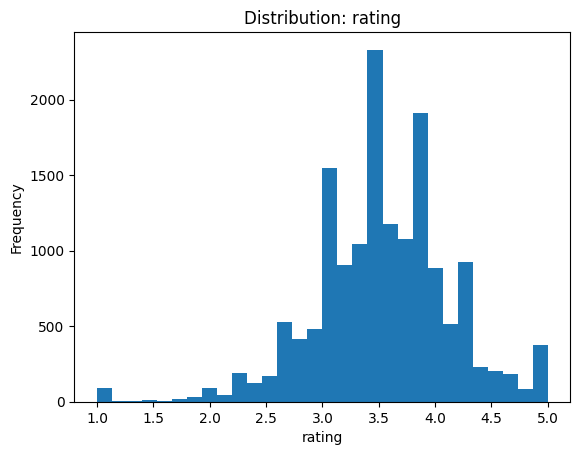

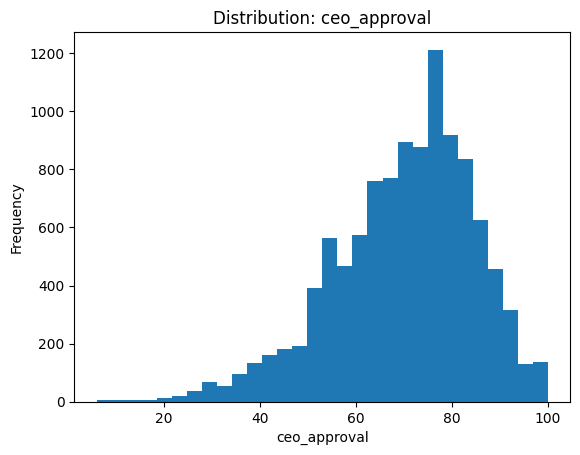

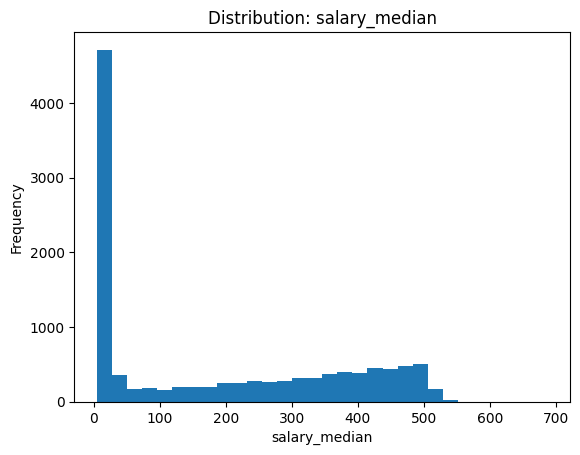

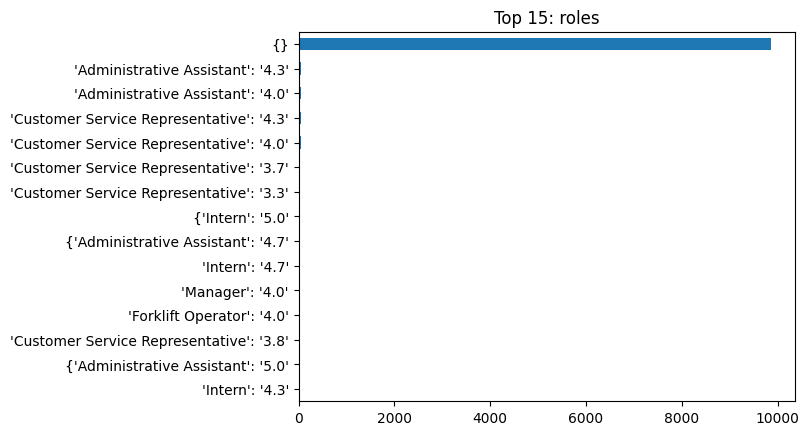

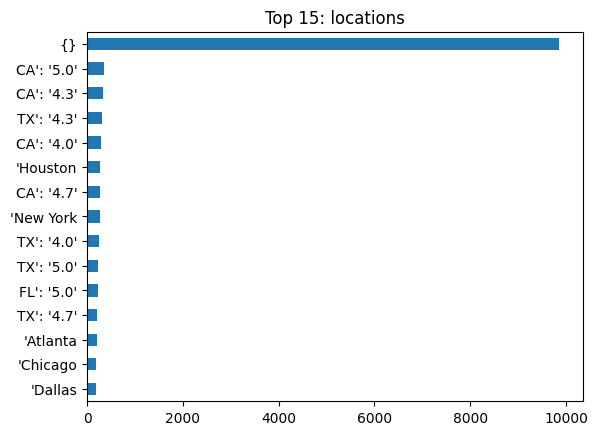

In [58]:
# Keep EDA tight (4–6 plots max). Add/remove columns based on your data.

def hist_if_exists(col):
    if col in df_clean.columns and df_clean[col].notna().any():
        plt.figure()
        df_clean[col].dropna().plot(kind="hist", bins=30, title=f"Distribution: {col}")
        plt.xlabel(col)
        plt.show()

for col in ["rating", "happiness", "ceo_approval", "salary_median"]:
    hist_if_exists(col)

# Top roles / locations (optional)
def top_k_listcol(col, k=15):
    if col not in df_clean.columns:
        return None
    items = []
    for lst in df_clean[col]:
        items.extend(lst if isinstance(lst, list) else [])
    s = pd.Series(items).value_counts().head(k)
    plt.figure()
    s.sort_values().plot(kind="barh", title=f"Top {k}: {col}")
    plt.show()
    return s

_ = top_k_listcol("roles", k=15)
_ = top_k_listcol("locations", k=15)


## 5) Build Retrieval Documents


In [42]:
# Define retrieval unit: start with 1 row -> 1 document.

NAME_COL = "name" if "name" in df_clean.columns else df_clean.columns[0]

def build_docs(df):
    docs = []
    for i, row in df.iterrows():
        meta = {"row_index": int(i), "company": str(row.get(NAME_COL, i))}
        # Keep a few structured signals for ranking/filters
        for c in ["rating","happiness","ceo_approval","salary_median","salary_min","salary_max","roles","locations"]:
            if c in df.columns:
                meta[c] = row.get(c)
        docs.append({"id": str(i), "text": str(row.get("doc_text","")), "meta": meta})
    return docs

docs = build_docs(df_clean)
print("Docs:", len(docs))
print("Example meta:", docs[0]["meta"])
print("Example text preview:", docs[0]["text"][:240])


Docs: 16712
Example meta: {'row_index': 0, 'company': 'Sitel', 'rating': nan, 'happiness': nan, 'ceo_approval': 70.0, 'salary_median': 12.96, 'salary_min': 11.44, 'salary_max': 14.48, 'roles': ["{'Tier 1 Agent': '5.0'", "'Director of Operations': '4.7'", "'Senior Vice President': '4.7'", "'Director of Finance': '4.7'", "'Sitel': '4.5'}"], 'locations': ["{'Paradise", "NV': '5.0'", "'Pioneer", "OH': '4.7'", "'Morocco", "IN': '4.6'", "'Kingston", "NY': '4.6'", "'Bartlett", "TN': '4.4'}"]}
Example text preview: Sitel Group’s 75,000 people across the globe connect many of the world’s best-known brands with their customers - 3.5 million times every day. As a global customer experience (CX) management leader, we apply our 30+ years of industry-leadin


## 6) Embeddings


In [44]:
from pathlib import Path
import os, sys, subprocess
import numpy as np

from src.config import EMBED_MODEL, ARTIFACT_DIR
from src.embeddings import embed_texts

# Ensure dependencies for embeddings
try:
    import sentence_transformers  # type: ignore
except Exception:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "sentence-transformers"])

# Ensure artifact dir exists
Path(ARTIFACT_DIR).mkdir(parents=True, exist_ok=True)

save_path = str(Path(ARTIFACT_DIR) / "embeddings.npy")

if os.path.exists(save_path):
    print(f"Loading embeddings from existing file: {save_path}")
    emb = np.load(save_path)
    print(f"Loaded embeddings shape: {emb.shape}")
elif "docs" in locals() and docs:
    texts = [d["text"] for d in docs]
    print(f"Generating embeddings for {len(texts)} documents with {EMBED_MODEL}...")

    emb = embed_texts(texts, EMBED_MODEL)

    np.save(save_path, emb)
    print(f"Saved embeddings: {save_path} {emb.shape}")
else:
    print("Variable 'docs' not found. Please run Section 5 (Build Retrieval Documents) first.")

Generating embeddings for 16712 documents with BAAI/bge-large-en-v1.5...


Batches:   0%|          | 0/262 [00:00<?, ?it/s]

Saved embeddings: /content/drive/MyDrive/pyramyd_ml/artifacts/embeddings.npy (16712, 1024)


## 7) FAISS Index


In [45]:
# FAISS setup + index build (do NOT generate src/index.py here)
import os, sys, subprocess
from pathlib import Path

try:
    import faiss  # type: ignore
except Exception:
    # Colab often supports faiss-gpu; local installs often use faiss-cpu
    in_colab_env = any(k in os.environ for k in ["COLAB_RELEASE_TAG", "COLAB_GPU", "COLAB_TPU_ADDR"])
    pkg = "faiss-gpu" if in_colab_env else "faiss-cpu"
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "faiss-cpu"]) # HARDCODE for now
    import faiss  # type: ignore

from src.index import build_index
from src.config import ARTIFACT_DIR

Path(ARTIFACT_DIR).mkdir(parents=True, exist_ok=True)

if "emb" in locals():
    print("Building FAISS index...")
    index = build_index(emb)

    index_path = str(Path(ARTIFACT_DIR) / "faiss.index")
    faiss.write_index(index, index_path)
    print(f"Saved index to {index_path}. Total vectors: {index.ntotal}")
else:
    print("Variable 'emb' not found. Please run Section 6 first.")

Building FAISS index...
Saved index to /content/drive/MyDrive/pyramyd_ml/artifacts/faiss.index. Total vectors: 16712


## 8) Retrieval + Filters Demo


In [47]:
# Retrieval demo (do NOT generate src/retrieval.py here)
from src.retrieval import search

if "index" in locals() and "docs" in locals():
    query = "i love coding and enjoy helping people"
    print(f"\nQuery: {query}")
    results = search(query, index, docs, top_k=3)
    for i, r in enumerate(results, start=1):
        company = (r.get("meta") or {}).get("company", "Unknown")
        print(f"[{i}] Score: {r['score']:.4f} | Company: {company}")
        print(f"    Text: {r['text'][:150]}...")
else:
    print("Skipping demo: 'index' or 'docs' not defined. Run Section 5–7 first.")


Query: i love coding and enjoy helping people
[1] Score: 0.6488 | Company: Techtonic
    Text: Great software development isn’t just rooted in the code; it’s reflected in the people you’re working with to accomplish your goals. At Techtonic we e...
[2] Score: 0.6322 | Company: Constant Contact
    Text: At Constant Contact, we build software products and provide marketing services to make small businesses and nonprofits more successful. So you could s...
[3] Score: 0.6293 | Company: HelpSystems
    Text: At HelpSystems, we are looking for talented professionals who are passionate about making life easier for modern organizations. In an increasingly dem...


## 9) Hybrid Ranking with User Priorities


In [48]:
# Hybrid ranking demo (do NOT generate src/ranker.py here)
from src.ranker import hybrid_score

if "results" in locals() and results:
    print("\n--- Re-ranking by Salary priority ---")
    priorities = {"salary": 0.5, "rating": 0.1}
    ranked = hybrid_score(results, priorities, alpha=0.7)
    for i, r in enumerate(ranked, start=1):
        sal = (r.get("meta") or {}).get("salary_median", "N/A")
        company = (r.get("meta") or {}).get("company", "Unknown")
        print(f"[{i}] Hybrid: {r['hybrid_score']:.4f} (Sem: {r['semantic_score_norm']:.4f}, Util: {r['utility_score']:.4f}) | Salary: {sal} | {company}")
else:
    print("Skipping ranking demo: 'results' not defined. Run retrieval section first.")


--- Re-ranking by Salary priority ---
[1] Hybrid: 0.7333 (Sem: 1.0000, Util: 0.1111) | Salary: nan | Techtonic
[2] Hybrid: 0.3552 (Sem: 0.1502, Util: 0.8333) | Salary: 493.0 | Constant Contact
[3] Hybrid: 0.0500 (Sem: 0.0000, Util: 0.1667) | Salary: 447.5 | HelpSystems


## 10) RAG Answer Generation (Grounded)


In [49]:
# RAG demo (do NOT generate src/rag.py here)
from src.config import LLM_MODEL
from src.llm import load_qwen_model
from src.rag import ask_rag

if "ranked" in locals() and ranked:
    # Lazy-load model only if needed (can take time / download weights)
    if "model" not in locals() or "tokenizer" not in locals():
        model, tokenizer = load_qwen_model(LLM_MODEL)

    query = locals().get("query", "data science")
    print("\n--- Generative Answer (Grounded) ---")
    answer = ask_rag(query, ranked[:3], model, tokenizer) # only use the first three results to generate
    print(answer)
else:
    print("Results not ready. Please run retrieval + ranking sections first.")


--- Generative Answer (Grounded) ---
- A short answer
Techtonic, Constant Contact, and HelpSystems are all great options for someone who loves coding and enjoys helping people.

- Top 3 recommendations
1. **Techtonic**
2. **Constant Contact**
3. **HelpSystems**

- Bullet reasons with citations
- **Techtonic** [1]
  - High hybrid_score (0.7333) indicating a strong alignment between the company's values and the candidate's interests.
  - Emphasizes collaboration, diverse perspectives, and a culture of critical thinking.
  - Mentions a focus on bringing together unique viewpoints, which aligns well with someone who enjoys helping others through problem-solving.

- **Constant Contact** [2]
  - High utility score (0.8333) suggesting a high value proposition for the employee.
  - Celebrates its employees with various recognition programs, indicating a supportive and rewarding work environment.
  - Focuses on making a positive impact on small businesses and nonprofits, which aligns with some

## 11) Side-by-Side Comparison


In [50]:
from src.rag import build_comparison_table, compare_companies_llm
from src.llm import load_qwen_model
from src.config import LLM_MODEL

if "ranked" in locals() and ranked:
    # Select top 3 for comparison
    top_results = ranked[:3]

    print("--- Side-by-Side Table ---")
    df_compare = build_comparison_table(top_results)
    display(df_compare)

    # Ensure model is loaded
    if "model" not in locals() or "tokenizer" not in locals():
        print("Loading LLM...")
        model, tokenizer = load_qwen_model(LLM_MODEL)

    print("\n--- LLM Comparison Summary ---")
    # Use the query from previous sections, or a default
    current_query = locals().get("query", "Compare these companies")
    comparison_text = compare_companies_llm(current_query, top_results, model, tokenizer)
    print(comparison_text)
else:
    print("No ranked results found. Please run Section 9 first.")


--- Side-by-Side Table ---


,Company,Rating,Salary Median,Happiness,Locations,Hybrid Score,Text Snippet
0,Techtonic,4.1,NaN,NaN,['{}'],0.733333,Great software development isn’t just rooted i...
1,Constant Contact,3.9,493.0,NaN,['{}'],0.355168,"At Constant Contact, we build software product..."
2,HelpSystems,4.2,447.5,NaN,['{}'],0.050000,"At HelpSystems, we are looking for talented pr..."



--- LLM Comparison Summary ---
### Comparison Summary: Techtonic vs. Constant Contact vs. HelpSystems

#### 1. **Culture and Atmosphere**

- **Techtonic**: Techtonic emphasizes a collaborative, diverse, and innovative culture. They value unique perspectives and critical thinking, aiming to create inclusive teams that reflect a variety of backgrounds and experiences. This fosters a dynamic and engaging work environment where employees are encouraged to bring their full selves to work [1].

- **Constant Contact**: Constant Contact is known for its collaborative, smart, friendly, and innovative atmosphere. The company places a strong emphasis on social responsibility, offering various initiatives such as volunteer time, annual charity auctions, and local scholarships. Employees often feel good about the positive impacts they have on their communities [2].

- **HelpSystems**: HelpSystems is described as having a fun, fast-paced work environment that values integrity, commitment, and kindn

## 12) Lightweight Evaluation


In [39]:
# Lightweight evaluation demo (uses src/eval.py)
from collections import defaultdict
from src.eval import EvalQuery, evaluate_retrieval, summarize

# Weak supervision example: query by company name and treat all rows of that company as relevant.
# This is imperfect, but gives a simple Recall@K signal without manual labeling.
if 'docs' in locals() and 'index' in locals():
    # Build company -> ids map
    company_to_ids = defaultdict(set)
    for d in docs:
        company = (d.get('meta') or {}).get('company')
        if company:
            company_to_ids[str(company)].add(str(d.get('id')))

    # Pick a few companies with multiple docs (adjust N as needed)
    candidates = [c for c, ids in company_to_ids.items() if len(ids) >= 2]
    print("Candidates:", candidates)
    sample_companies = candidates[:5]
    eval_set = [EvalQuery(query=c, relevant_ids=frozenset(company_to_ids[c])) for c in sample_companies]

    if not eval_set:
        print("No suitable companies found for weak-supervision eval.")
    else:
        rows = evaluate_retrieval(index=index, docs=docs, queries=eval_set, k=10)
        for r in rows:
            print(f"query={r.query!r} recall@{r.k}={r.recall_at_k:.3f} latency_ms={r.latency_ms:.1f}")
        print("\nSummary:", summarize(rows))
else:
    print("Run retrieval/index sections first so 'docs' and 'index' exist.")

Candidates: ['nan', 'EvergreenHealth', 'Crown Automotive', 'Covenant Care', 'Keeper Security', 'Mosaic', "The Children's Village", 'Covenant Health', 'Unity Hospice', 'EMSI', 'Exer More Than Urgent Care', 'The Strater Hotel', 'Glendale Community College', 'Voyage Healthcare', 'Westminster Village', 'Florida Hospital Home Infusion', 'Lakeview Hospital', 'Swedish Medical Center', 'RTC']
query='nan' recall@10=0.000 latency_ms=29.4
query='EvergreenHealth' recall@10=0.000 latency_ms=26.8
query='Crown Automotive' recall@10=1.000 latency_ms=26.6
query='Covenant Care' recall@10=1.000 latency_ms=26.6
query='Keeper Security' recall@10=1.000 latency_ms=26.7

Summary: {'avg_recall_at_k': 0.6, 'avg_mrr_at_k': 0.5, 'avg_ndcg_at_k': 0.5226294385530916, 'avg_latency_ms': 27.199621999898227}


## 13) Gradio Demo UI


In [ ]:
# Gradio demo UI (uses src/ui.py)
from src.ui import build_app

# Set to True if you want to launch the UI from the notebook.
LAUNCH_UI = False

demo = build_app()
print("UI built. Set LAUNCH_UI=True to launch.")
if LAUNCH_UI:
    demo.launch(share=True)

## 14) Save Artifacts + Local Run Notes


In [ ]:
# Optional artifact bundling:
# import shutil
# shutil.make_archive("artifacts_bundle", "zip", ARTIFACT_DIR)
# print("Created artifacts_bundle.zip")


## 15) Resume Bullets & Next Steps

- Built a RAG-based product discovery engine with FAISS semantic search over company reviews + metadata.
- Designed a hybrid ranking model combining embedding similarity with structured signals and user-weighted priorities.
- Deployed an interactive Gradio UI enabling natural-language search, filtering, and AI side-by-side comparisons with citations.
